In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from lsv.utils import implied_volatility
from lsv.local_vol import SyntheticMarketSurface
from lsv.leverage import simulate_heston_paths, compute_leverage_function
from lsv.monte_carlo import simulate_lsv_paths
import kaleido

In [2]:
S0 = 100.0
r = 0.02
q = 0.01

v0 = 0.04          
kappa = 2.0        
theta = 0.04       
sigma_h = 0.3      
rho_h = -0.6       

T_max = 1.0
N_steps = 100
T_grid = np.linspace(0.0, T_max, N_steps + 1)
moneyness_grid = np.linspace(0.6, 1.3, 30)

In [3]:
market = SyntheticMarketSurface(S0, r, q)

target_iv_surface = np.zeros((len(moneyness_grid), len(T_grid)))
local_vol_surface = np.zeros((len(moneyness_grid), len(T_grid)))

for i, m in enumerate(moneyness_grid):
    K = m * S0
    for j, t in enumerate(T_grid):
        target_iv_surface[i, j] = market.implied_vol(K, t)
        local_vol_surface[i, j] = market.local_vol_dupire(K, t)

C:\Users\aghlo\Documents\Python_projects\LSV\lsv\local_vol.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  return self.eta / (theta ** self.gamma)
C:\Users\aghlo\Documents\Python_projects\LSV\lsv\local_vol.py:28: RuntimeWarning: invalid value encountered in scalar multiply
  w = 0.5 * theta_t * (1 + self.rho * phi_t * k + sqrt_term)
C:\Users\aghlo\Documents\Python_projects\LSV\lsv\local_vol.py:28: RuntimeWarning: invalid value encountered in scalar add
  w = 0.5 * theta_t * (1 + self.rho * phi_t * k + sqrt_term)


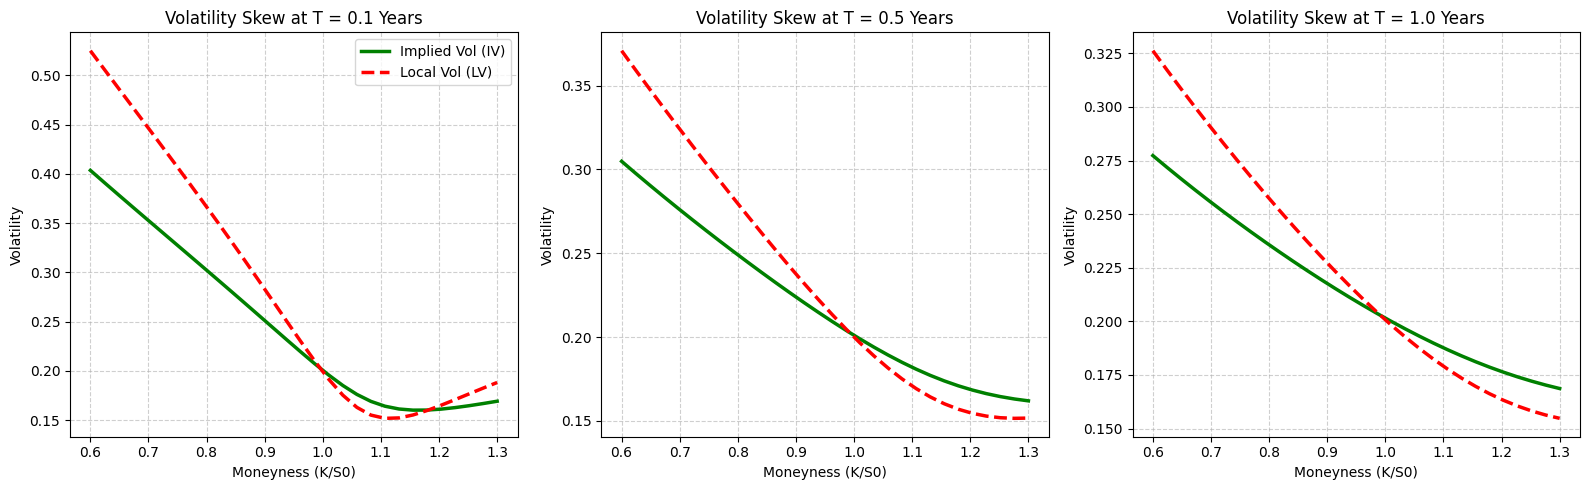

In [4]:
selected_maturities_y = [0.1, 0.5, 1.0]
selected_indices = [np.abs(T_grid - t).argmin() for t in selected_maturities_y]

plt.figure(figsize=(16, 5))

for idx_fig, idx_T in enumerate(selected_indices):
    t = T_grid[idx_T]
    plt.subplot(1, len(selected_maturities_y), idx_fig + 1)
    
    target_iv_skew = target_iv_surface[:, idx_T]
    local_vol_skew = local_vol_surface[:, idx_T]
    
    plt.plot(moneyness_grid, target_iv_skew, label='Implied Vol (IV)', color='green', linewidth=2.5)
    plt.plot(moneyness_grid, local_vol_skew, label='Local Vol (LV)', color='red', linestyle='--', linewidth=2.5)
    
    plt.title(f'Volatility Skew at T = {t:.1f} Years')
    plt.xlabel('Moneyness (K/S0)')
    plt.ylabel('Volatility')
    plt.grid(True, linestyle='--', alpha=0.6)
    if idx_fig == 0: plt.legend()

plt.tight_layout()
plt.savefig("../images/volatility_skew_comparaison_for_different_maturities.png", dpi=200)

In [5]:
S_h, V_h = simulate_heston_paths(
    S0, r, q, kappa, theta, sigma_h, rho_h, v0, T_grid, N_paths=15000
)

L, spline_L = compute_leverage_function(
    local_vol_surface, S_h, V_h, moneyness_grid, T_grid, S0
)

In [6]:
S_lsv = simulate_lsv_paths(
    S0, r, q, kappa, theta, sigma_h, rho_h, v0, spline_L, T_grid, N_paths=20000
)

lsv_iv_surface = np.zeros((len(moneyness_grid), len(T_grid)))

for i, m in enumerate(moneyness_grid):
    K = m * S0
    for j, t in enumerate(T_grid):
        if t < 0.05: 
            lsv_iv_surface[i, j] = np.nan
            continue
            
        opt_type = 'call' if K >= S0 * np.exp((r-q)*t) else 'put'
        payoff = np.maximum(S_lsv[:, j] - K, 0) if opt_type == 'call' else np.maximum(K - S_lsv[:, j], 0)
        price = np.exp(-r * t) * np.mean(payoff)
        
        lsv_iv_surface[i, j] = implied_volatility(S0, K, t, r, q, price, opt_type)

In [7]:
T_p = T_grid[5:]
M_p = moneyness_grid
Z_iv = target_iv_surface[:, 5:]
Z_lv = local_vol_surface[:, 5:]

fig = go.Figure()

fig.add_trace(go.Surface(
    x=T_p, y=M_p, z=Z_iv,
    colorscale='Viridis',
    name='Implied Vol ', 
    showscale=False,
    showlegend=True,             
    opacity=0.8
))

fig.add_trace(go.Surface(
    x=T_p, y=M_p, z=Z_lv,
    colorscale='Plasma',
    name='LSV',   
    showscale=False,
    showlegend=True,             
    opacity=0.8
))

fig.update_layout(
    title='Implied Vol vs LSV Surfaces',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    ),
    scene=dict(
        xaxis_title='Maturity (Years)',
        yaxis_title='Moneyness',
        zaxis_title='Volatility',
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=0.7) 
    ),
    margin=dict(l=0, r=0, b=0, t=40), 
    width=700,
    height=500
)

fig.write_image("../images/implied_vs_lsv_surfaces.png", scale=2 , width=700, height=700)